In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

import seaborn as sns 
from collections import Counter

import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.regularizers import L2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Adadelta, Nadam

import keras_tuner as kt
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks, NearMiss


2024-03-28 09:58:47.291824: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-28 09:58:47.295387: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-28 09:58:47.318297: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-03-28 09:58:49.420916: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
tf.config.experimental.set_visible_devices([], 'GPU')

2024-03-28 09:59:27.499864: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-28 09:59:28.018223: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-28 09:59:28.018309: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


# Utils definitions

In [3]:
def encode_objects(df):
    for col, dtype in df.dtypes.items():
        if dtype == 'object' and col != 'label':
            encoder = LabelEncoder()
            df[col] = encoder.fit_transform(df[col])
    return df

def scale_objects(df, scaler):
    array_scaled = scaler.transform(df)
    df_scaled = pd.DataFrame(array_scaled, columns=df.columns)
    return df_scaled

def df_boxplots(df):
    for col, dtype in df.dtypes.items():
        if col not in ['protocol_type', 'flag', 'logged_in', 'label']:
            fig = plt.figure(figsize=(10,7))
            plt.boxplot(df[col], vert=0)
            plt.ylabel(col)
            plt.show()

def df_hist(df):
    for col, dtype in df.dtypes.items():
        if col not in ['protocol_type', 'flag', 'logged_in', 'label']:
            fig = plt.figure(figsize=(10,7))
            plt.hist(df[col])
            plt.xlabel(col)
            plt.ylabel('Frequency')
            plt.show()

# Reading and checking dataset out

In [4]:
columns = ["duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent",
        "hot", "num_failed_logins", "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root", 
        "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
        "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate", "srv_rerror_rate",
        "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count", 
        "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate", "dst_host_srv_diff_host_rate",
        "dst_host_serror_rate", "dst_host_srv_serror_rate", "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label"]

df_init = pd.read_csv("datasets/kddcup1999/kddcup.data.corrected", sep=",", names=columns, index_col=None)

In [5]:
df_init['label'].value_counts()

label
smurf.              2807886
neptune.            1072017
normal.              972781
satan.                15892
ipsweep.              12481
portsweep.            10413
nmap.                  2316
back.                  2203
warezclient.           1020
teardrop.               979
pod.                    264
guess_passwd.            53
buffer_overflow.         30
land.                    21
warezmaster.             20
imap.                    12
rootkit.                 10
loadmodule.               9
ftp_write.                8
multihop.                 7
phf.                      4
perl.                     3
spy.                      2
Name: count, dtype: int64

In [6]:
df_init['service'].value_counts()

service
ecr_i        2811660
private      1100831
http          623091
smtp           96554
other          72653
              ...   
tftp_u             3
harvest            2
aol                2
http_8001          2
http_2784          1
Name: count, Length: 70, dtype: int64

# Preprocessing

## Feature selection

In [7]:
# Keeping only the features selected in the paper A stacking... by Smitha Rajagopal

keep_cols = ['logged_in', 'count', 'dst_host_count', 'protocol_type', 'srv_count', 'dst_host_same_src_port_rate', 'srv_diff_host_rate', 'dst_bytes', 'serror_rate', 'srv_serror_rate', 'same_srv_rate', 'flag', 'dst_host_same_srv_rate', 'dst_host_srv_count', 'dst_host_srv_diff_host_rate', 'label']

df_feature_selected = df_init[df_init.columns.intersection(keep_cols)]

In [8]:
df_feature_selected.head()

,protocol_type,flag,dst_bytes,logged_in,count,srv_count,serror_rate,srv_serror_rate,same_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,label
0,tcp,SF,45076,1,1,1,0.0,0.0,1.0,0.0,0,0,0.0,0.00,0.0,normal.
1,tcp,SF,4528,1,2,2,0.0,0.0,1.0,0.0,1,1,1.0,1.00,0.0,normal.
2,tcp,SF,1228,1,1,1,0.0,0.0,1.0,0.0,2,2,1.0,0.50,0.0,normal.
3,tcp,SF,2032,1,2,2,0.0,0.0,1.0,0.0,3,3,1.0,0.33,0.0,normal.
4,tcp,SF,486,1,3,3,0.0,0.0,1.0,0.0,4,4,1.0,0.25,0.0,normal.


In [9]:
df_feature_selected.shape

(4898431, 16)

In [10]:
# Encoding data

df_feature_selected_encoded = encode_objects(df_feature_selected)

/tmp/ipykernel_22014/3865037305.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = encoder.fit_transform(df[col])
/tmp/ipykernel_22014/3865037305.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = encoder.fit_transform(df[col])


In [11]:
df_feature_selected_encoded['label'] = df_feature_selected_encoded['label'].apply(lambda x: 0 if x=='normal.' else 1)

/tmp/ipykernel_22014/1445368458.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_feature_selected_encoded['label'] = df_feature_selected_encoded['label'].apply(lambda x: 0 if x=='normal.' else 1)


In [12]:
df_feature_selected_encoded['label'].value_counts()

label
1    3925650
0     972781
Name: count, dtype: int64

## Visualizing distributions

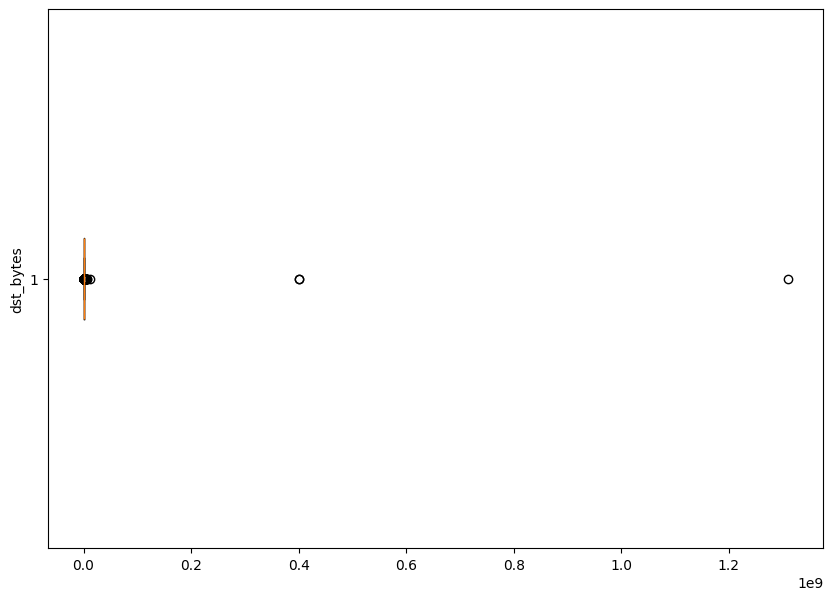

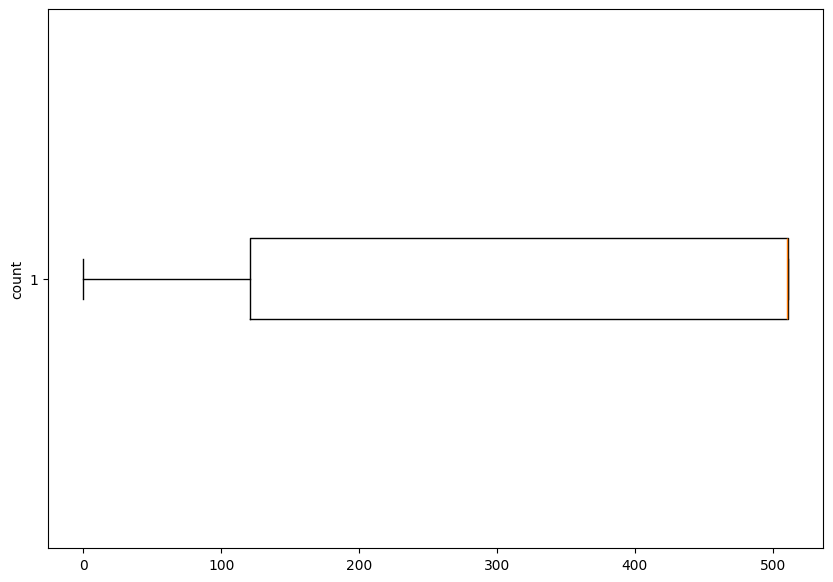

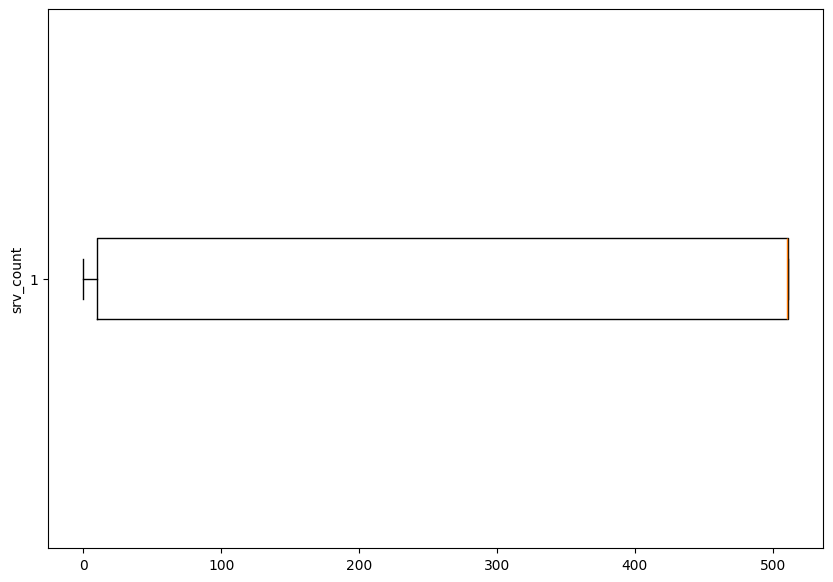

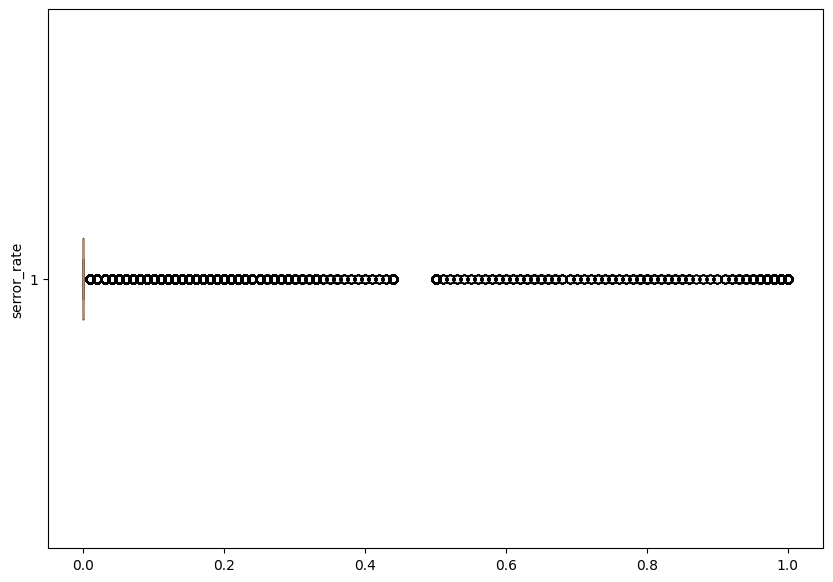

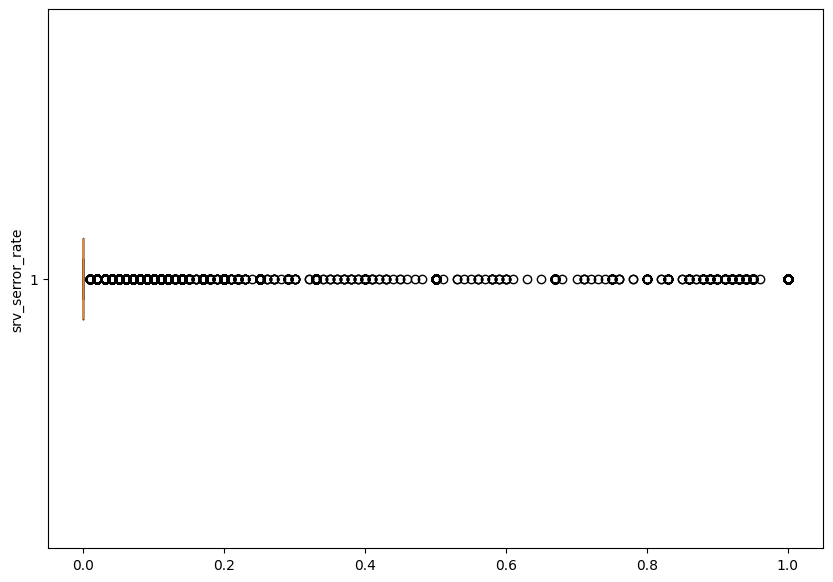

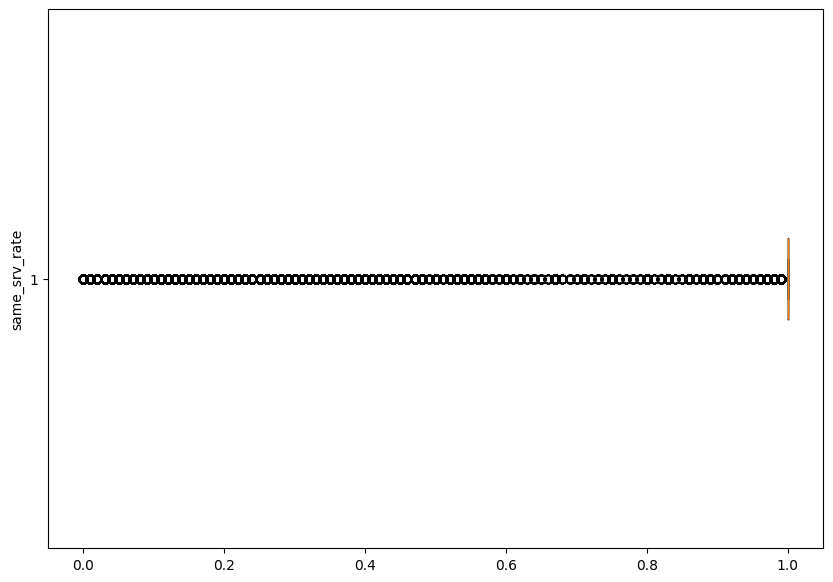

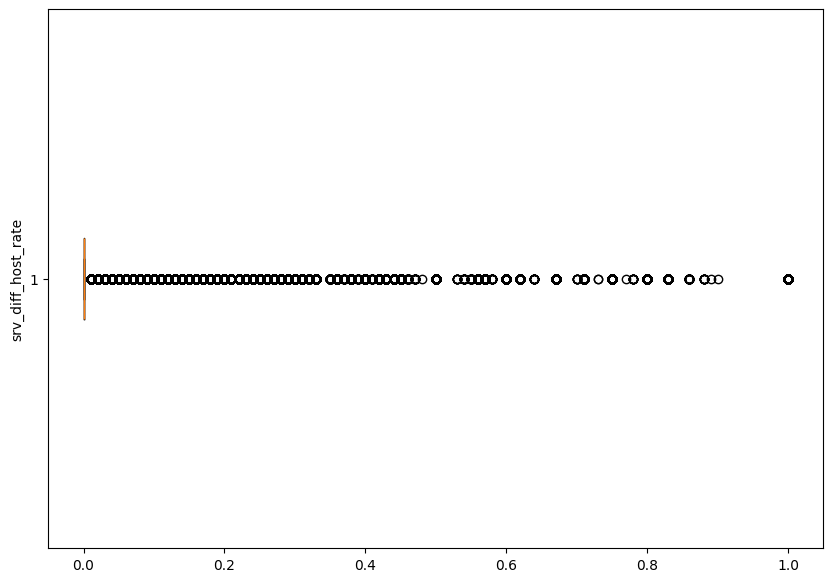

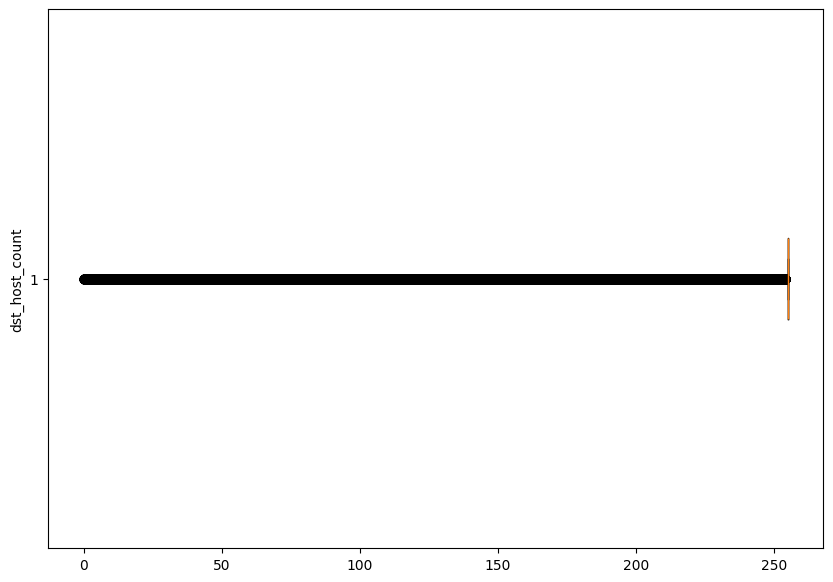

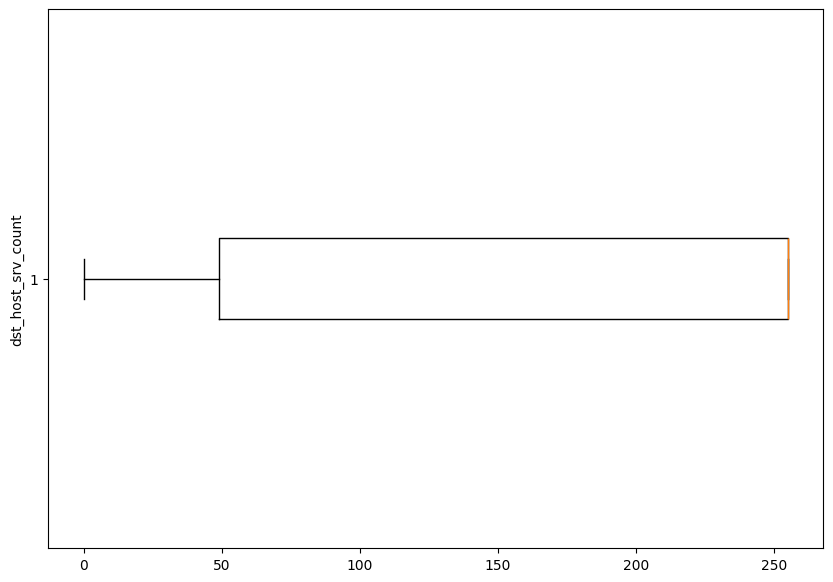

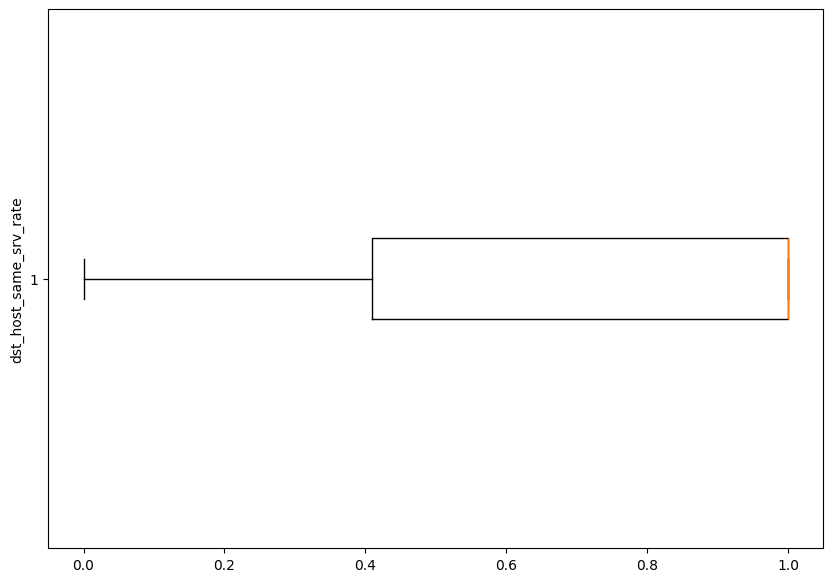

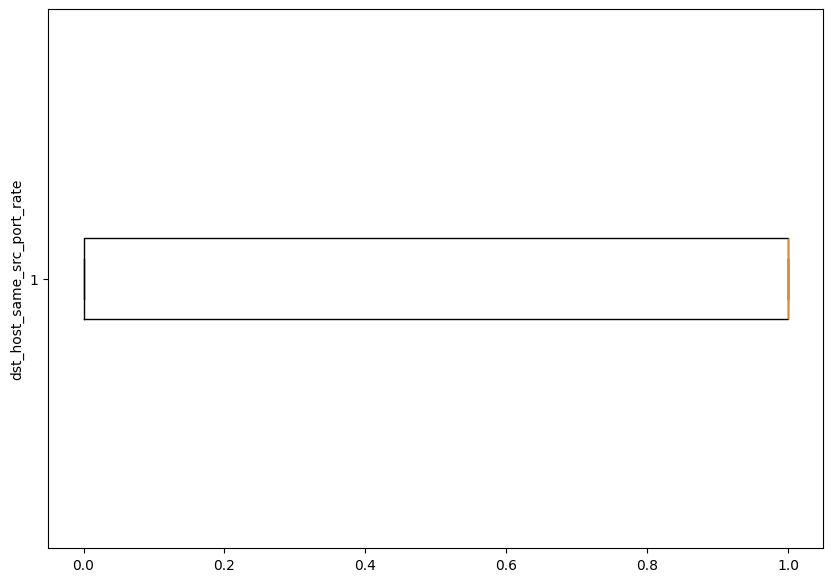

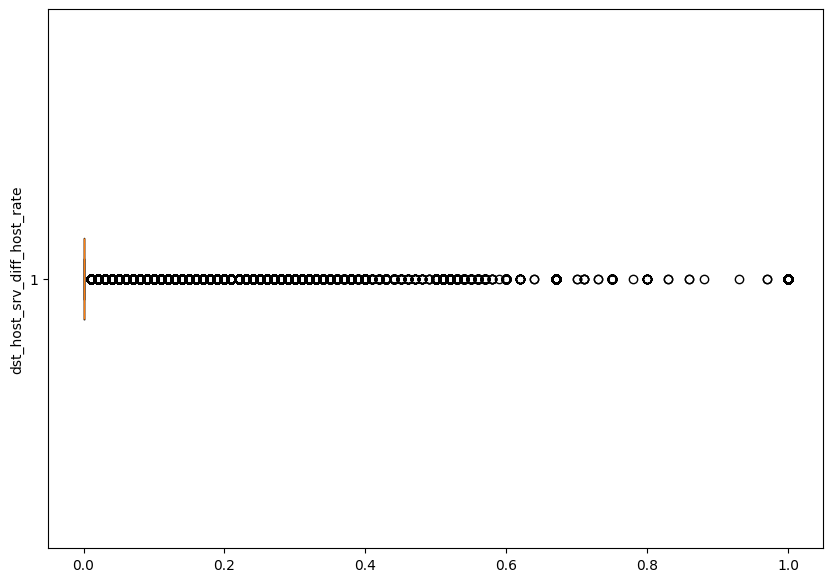

In [13]:
df_boxplots(df_feature_selected_encoded)

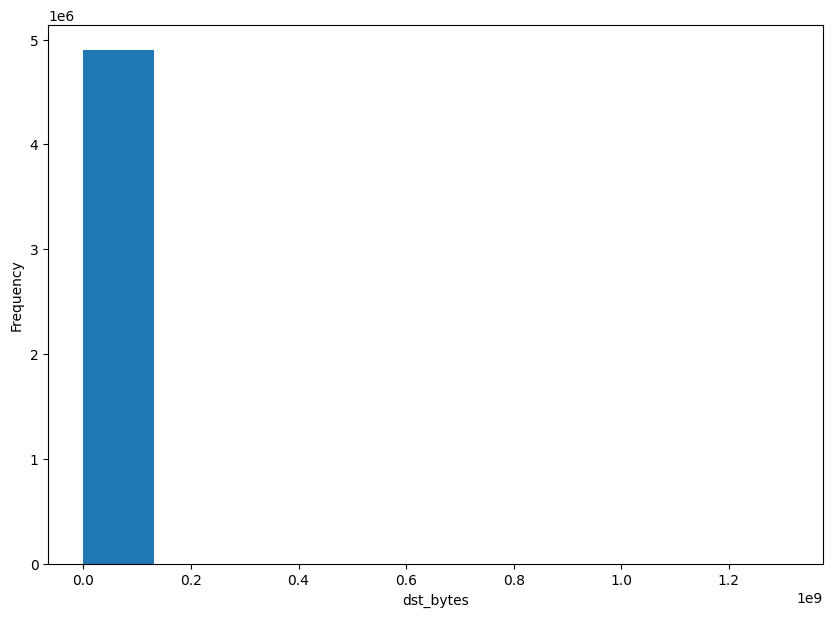

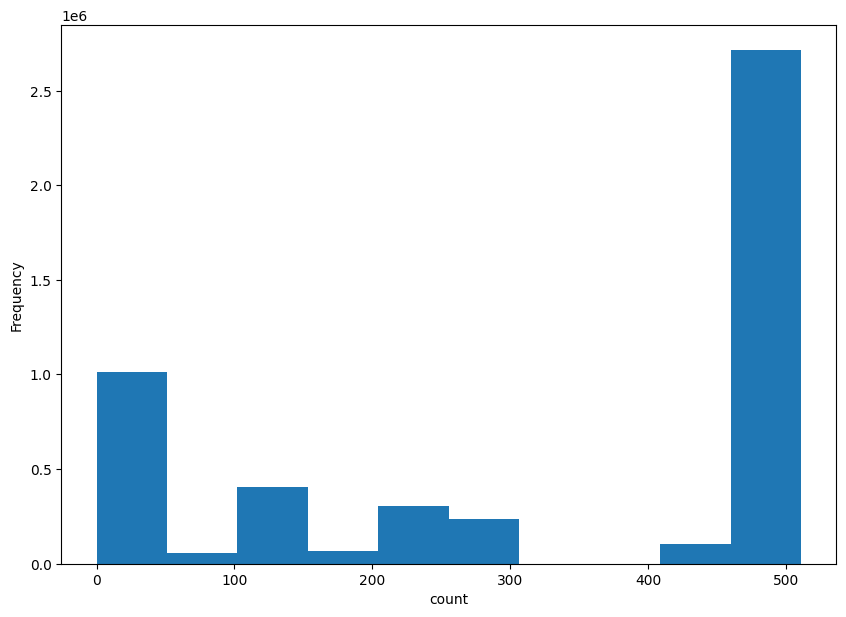

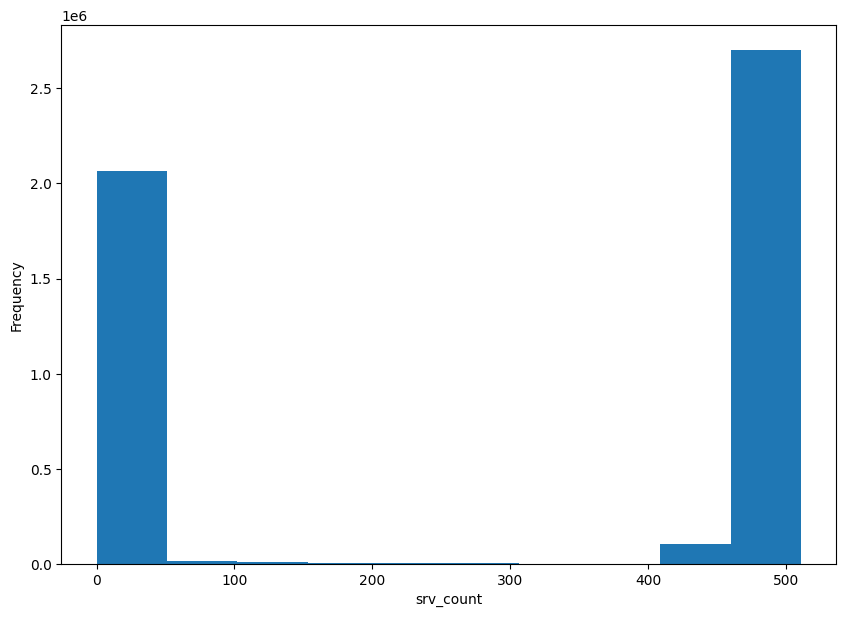

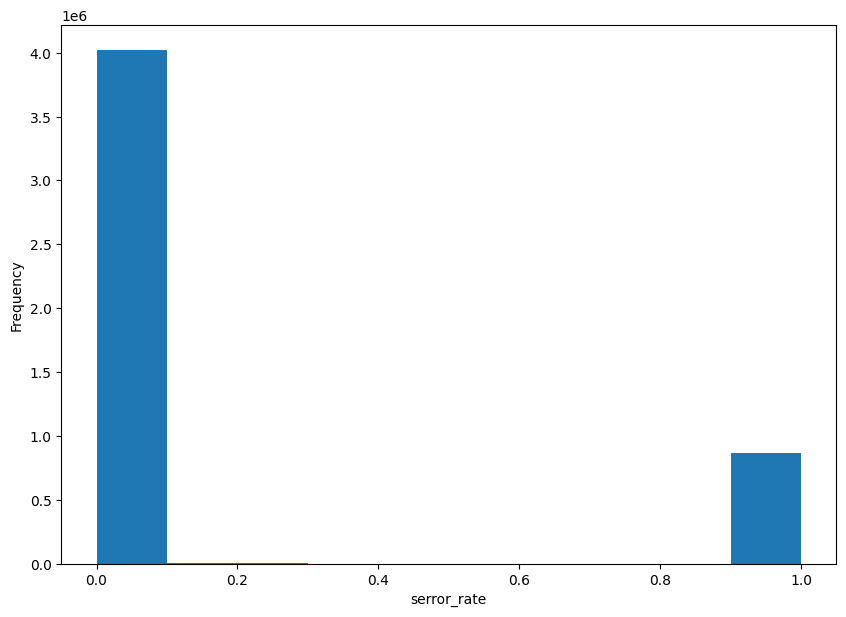

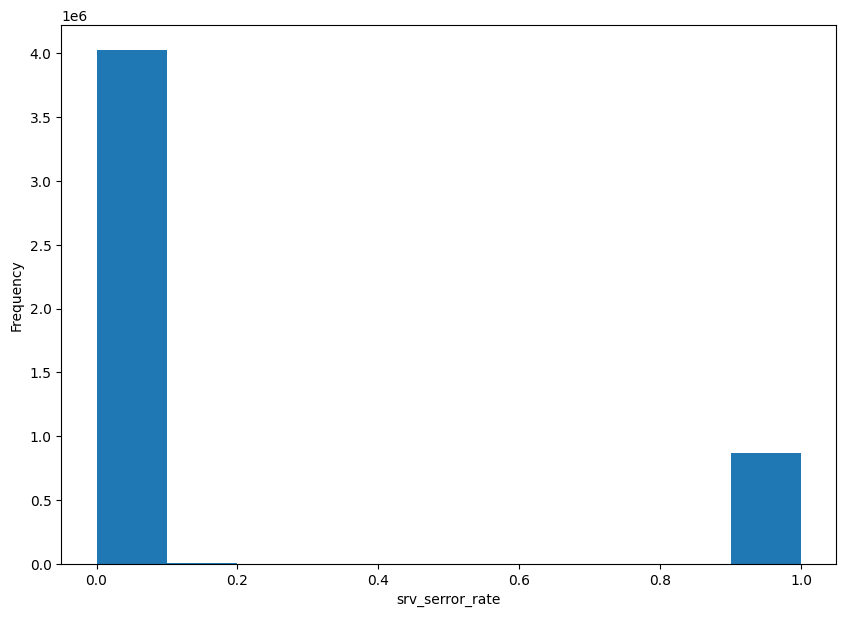

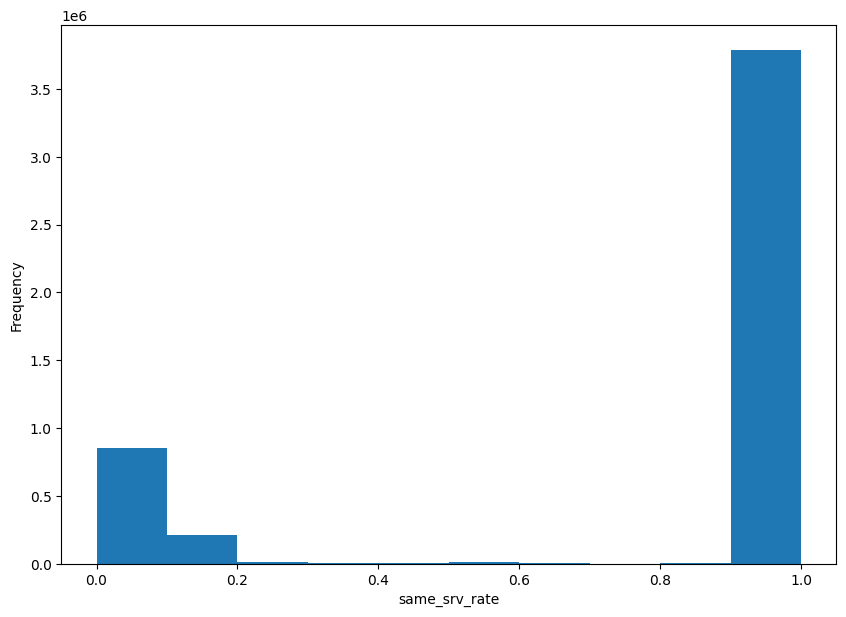

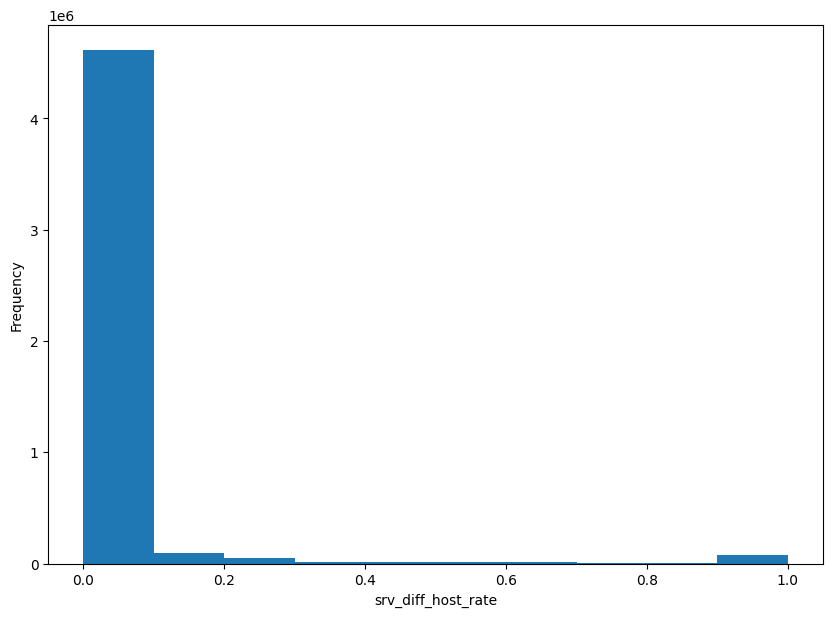

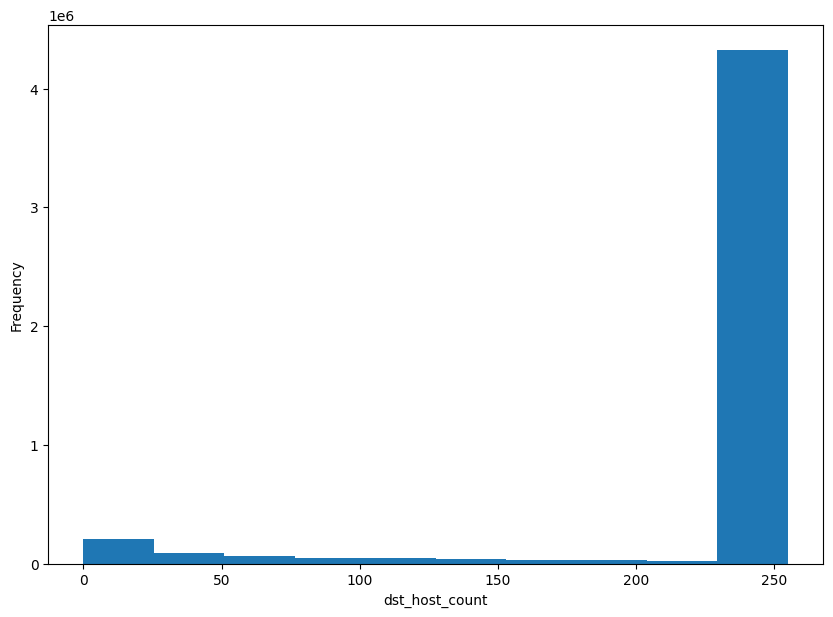

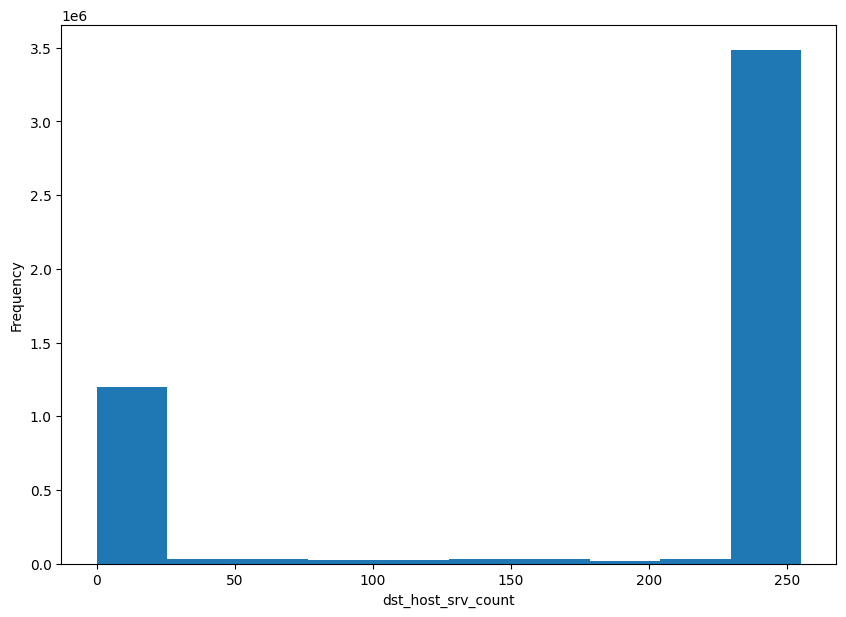

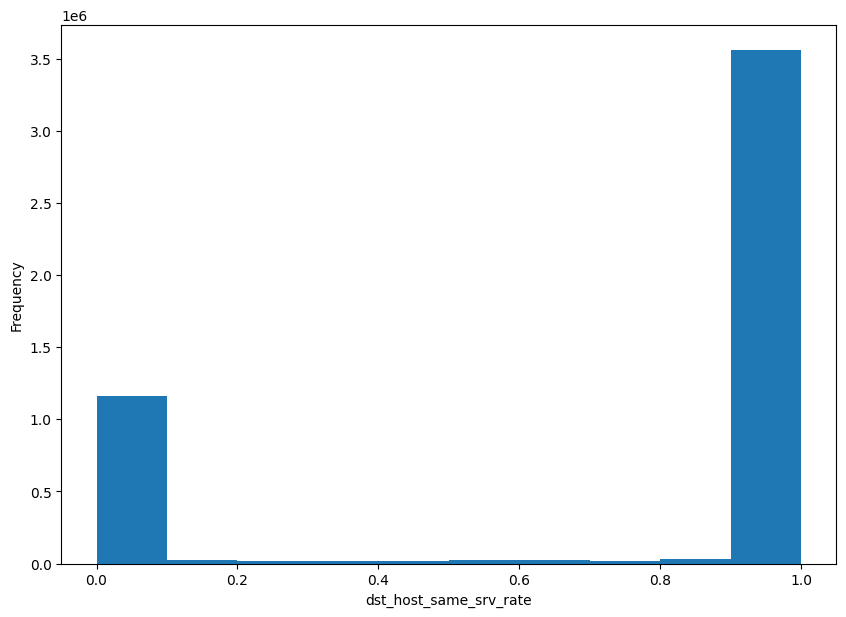

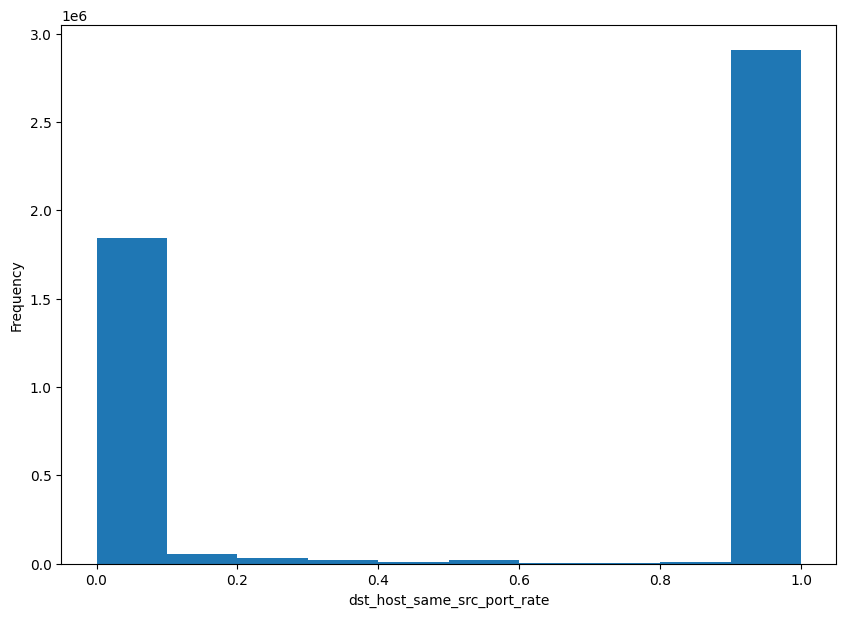

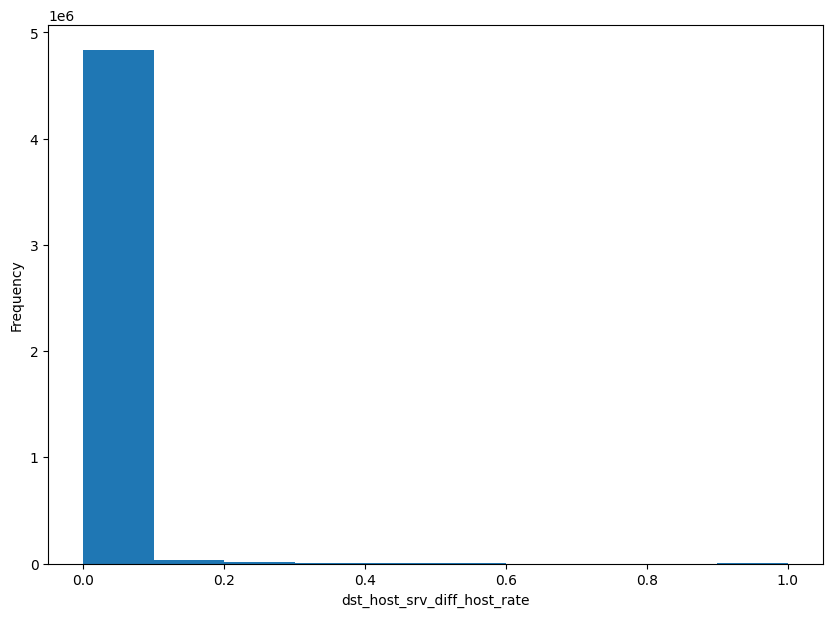

In [14]:
df_hist(df_feature_selected_encoded)

## Removing outliers

In [15]:
df_feature_selected_encoded[df_feature_selected_encoded['dst_bytes'] > 1e8]

,protocol_type,flag,dst_bytes,logged_in,count,srv_count,serror_rate,srv_serror_rate,same_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,label
1415575,1,4,400291060,0,1,1,0.0,0.0,1.0,0.0,255,1,0.00,1.0,0.0,1
1415576,1,4,400291060,0,2,2,0.0,0.0,1.0,0.0,255,2,0.01,1.0,0.0,1
1417571,1,4,1309937401,0,1,1,0.0,0.0,1.0,0.0,255,1,0.00,1.0,0.0,1


In [16]:
df_feature_selected_encoded.shape

(4898431, 16)

In [17]:
df_feature_selected_encoded = df_feature_selected_encoded.drop(df_feature_selected_encoded[df_feature_selected_encoded['dst_bytes'] > 2e8].index)
df_feature_selected_encoded.shape

(4898428, 16)

In [18]:
normal = df_feature_selected_encoded.query('label == 0').sample(100000)
attack = df_feature_selected_encoded.query('label == 1').sample(100000)

df_reduced = pd.concat([normal, attack])
df_reduced

,protocol_type,flag,dst_bytes,logged_in,count,srv_count,serror_rate,srv_serror_rate,same_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,label
266235,1,9,1839,1,1,3,0.0,0.0,1.0,1.00,157,107,0.22,0.01,0.02,0
806133,1,9,363,1,1,2,0.0,0.0,1.0,1.00,78,175,0.59,0.01,0.01,0
3406998,1,9,334,1,1,1,0.0,0.0,1.0,0.00,119,55,0.46,0.01,0.00,0
313250,1,9,1257,1,11,14,0.0,0.0,1.0,0.14,255,255,1.00,0.00,0.00,0
14436,1,9,2438,1,7,16,0.0,0.0,1.0,0.25,21,255,1.00,0.05,0.05,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4141081,0,9,0,0,511,511,0.0,0.0,1.0,0.00,255,255,1.00,1.00,0.00,1
1990817,0,9,0,0,510,510,0.0,0.0,1.0,0.00,255,255,1.00,1.00,0.00,1
4238166,0,9,0,0,511,511,0.0,0.0,1.0,0.00,255,255,1.00,1.00,0.00,1
2759478,0,9,0,0,511,511,0.0,0.0,1.0,0.00,255,255,1.00,1.00,0.00,1


## Creating test, train, validation dataframes

In [19]:
labels = df_reduced['label']
features = df_reduced.drop("label", axis=1)

In [20]:
x_train, x_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

In [21]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.3, random_state=42)

In [22]:
print("Shapes")
print(f"x_train:{x_train.shape}\ny_train:{y_train.shape}")
print(f"\nx_val:{x_val.shape}\ny_val:{y_val.shape}")
print(f"\nx_test:{x_test.shape}\ny_test:{y_test.shape}")

Shapes
x_train:(112000, 15)
y_train:(112000,)

x_val:(48000, 15)
y_val:(48000,)

x_test:(40000, 15)
y_test:(40000,)


In [23]:
print(Counter(y_train))
print(Counter(y_val))

Counter({0: 56075, 1: 55925})
Counter({1: 24068, 0: 23932})


## Normalizing data

In [24]:
scaler = MinMaxScaler()
scaler.fit(x_train)
x_train = scale_objects(x_train, scaler)
x_val = scale_objects(x_val, scaler)
x_train = scale_objects(x_train, scaler)

In [40]:
x_test

,protocol_type,flag,dst_bytes,logged_in,count,srv_count,serror_rate,srv_serror_rate,same_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate
4240890,0,9,0,0,511,511,0.0,0.0,1.00,0.00,255,255,1.00,1.00,0.00
497737,1,9,328,1,1,1,0.0,0.0,1.00,0.00,231,161,0.63,0.00,0.01
4197152,0,9,0,0,511,511,0.0,0.0,1.00,0.00,255,255,1.00,1.00,0.00
4551224,1,9,6660,1,6,6,0.0,0.0,1.00,0.00,236,255,1.00,0.00,0.01
4890364,1,9,2803,1,4,6,0.0,0.0,1.00,0.33,4,255,1.00,0.25,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395286,1,9,141,0,1,1,0.0,0.0,1.00,0.00,5,7,0.20,0.20,0.29
4877575,1,9,1270,1,5,5,0.0,0.0,1.00,0.00,255,255,1.00,0.00,0.00
2380090,0,9,0,0,511,511,0.0,0.0,1.00,0.00,255,255,1.00,1.00,0.00
1104913,1,5,0,0,111,10,1.0,1.0,0.09,0.00,255,10,0.04,0.00,0.00


### Visualise scaled data histograms

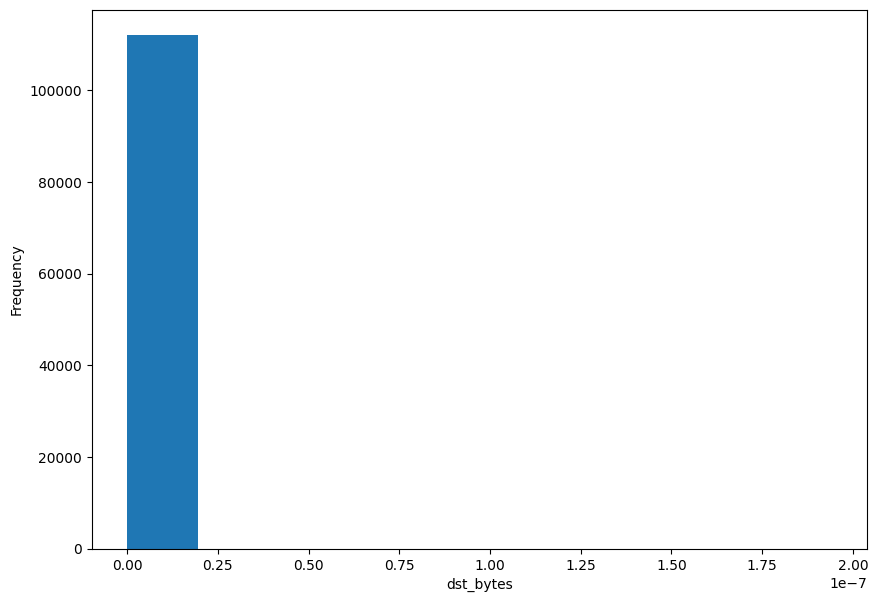

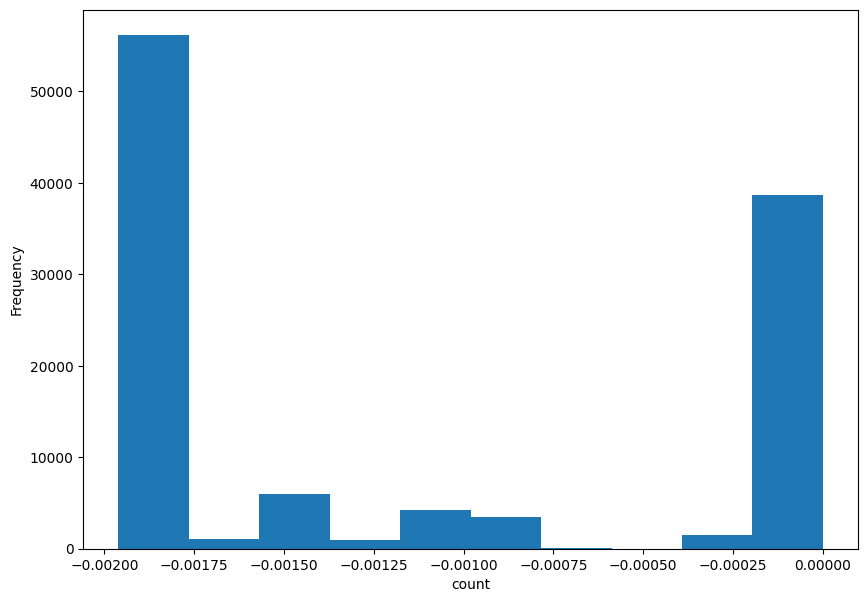

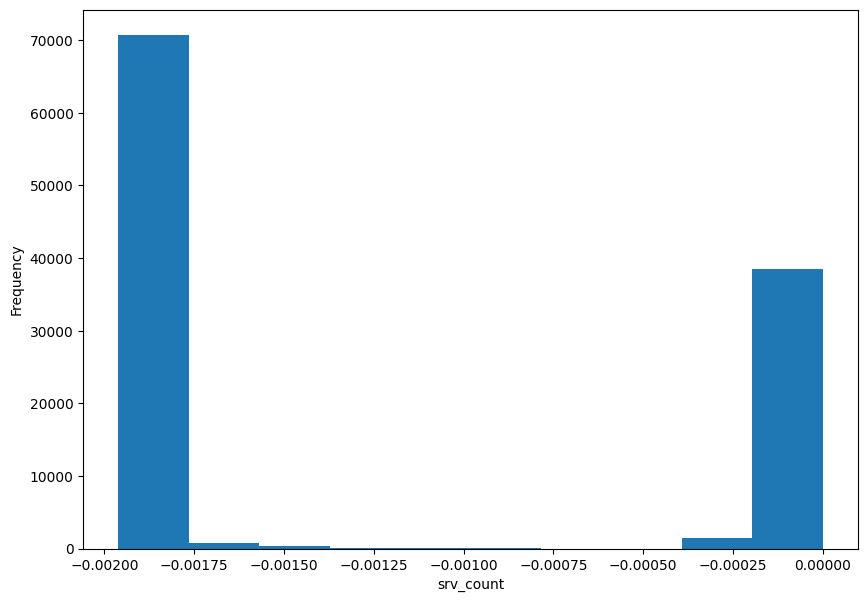

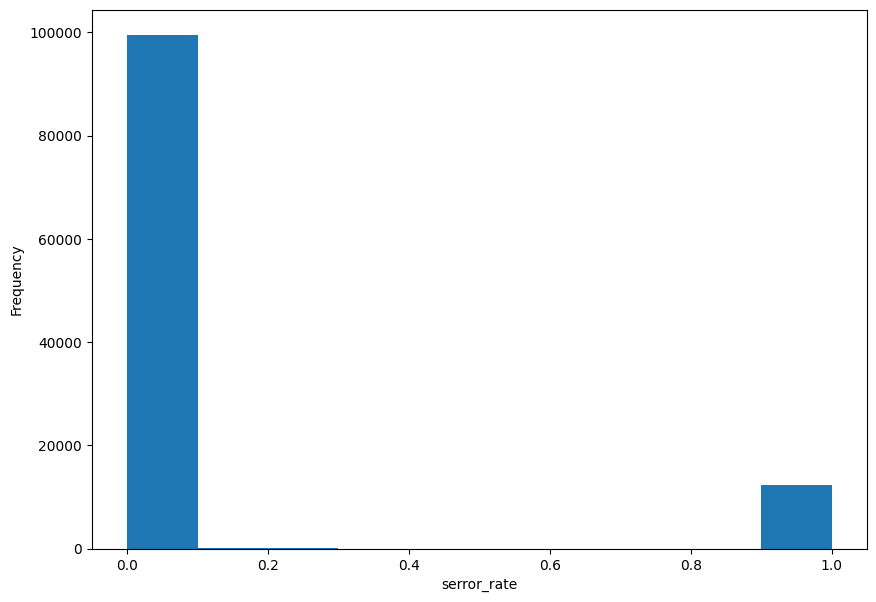

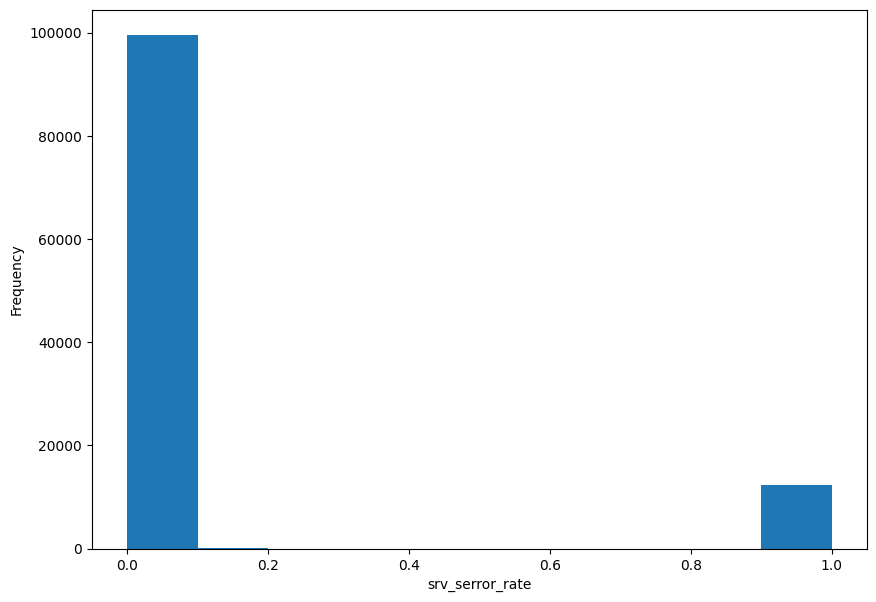

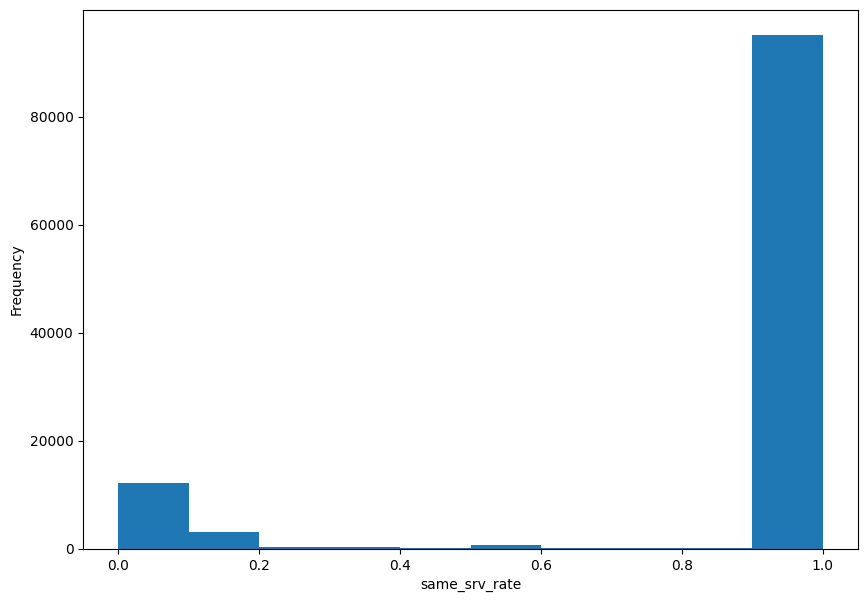

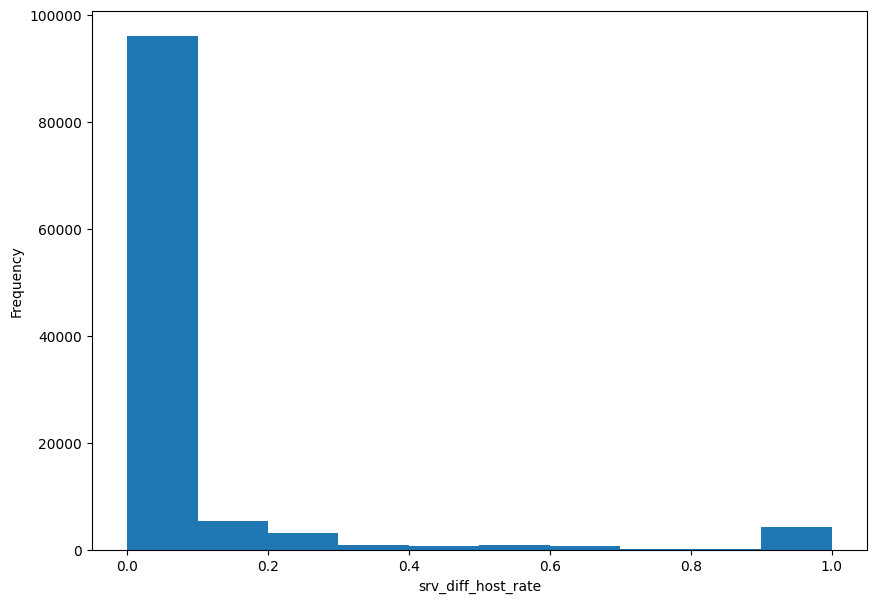

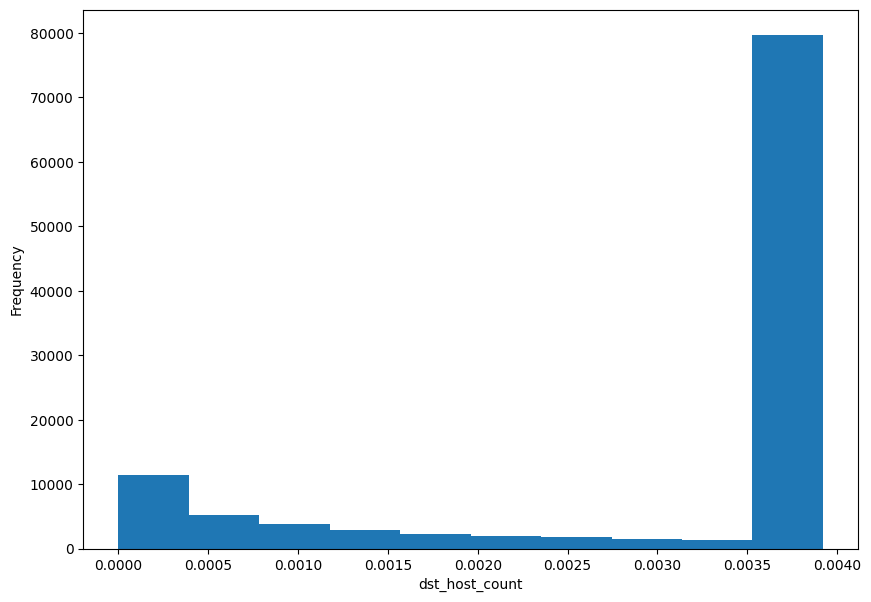

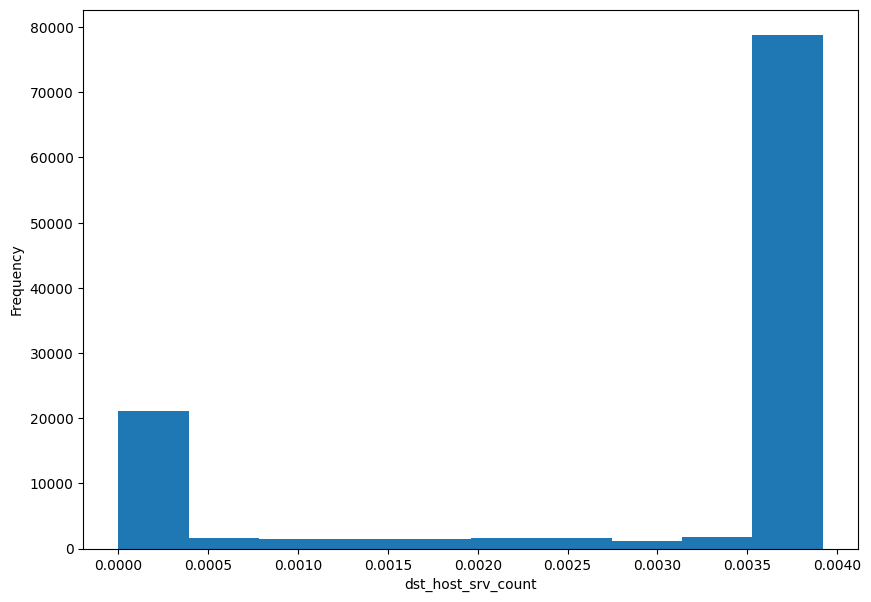

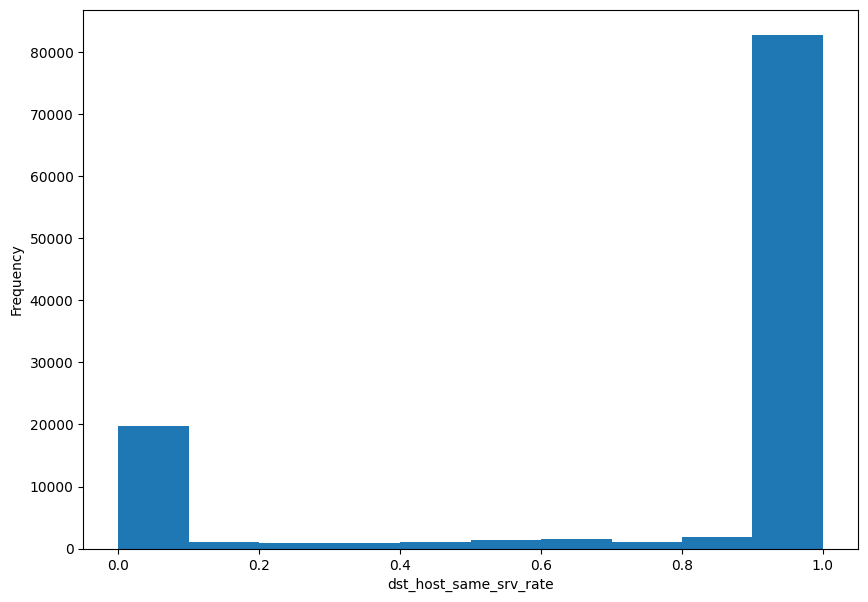

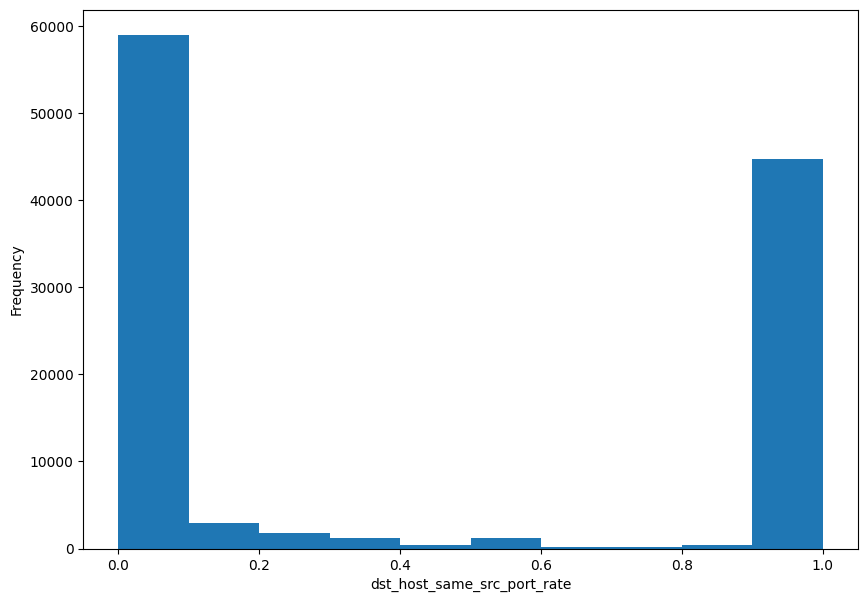

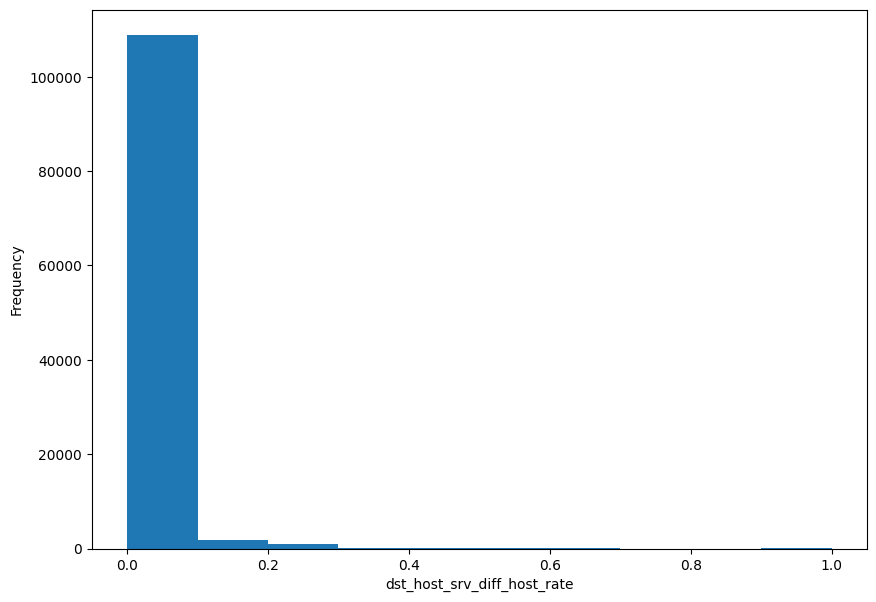

In [25]:
df_hist(x_train)

In [26]:
y_train =  to_categorical(y_train)
y_test =  to_categorical(y_test)
y_val =  to_categorical(y_val)

In [27]:
print("Shapes")
print(f"x_train:{x_train.shape}\ny_train:{y_train.shape}")
print(f"\nx_val:{x_val.shape}\ny_val:{y_val.shape}")
print(f"\nx_test:{x_test.shape}\ny_test:{y_test.shape}")

Shapes
x_train:(112000, 15)
y_train:(112000, 2)

x_val:(48000, 15)
y_val:(48000, 2)

x_test:(40000, 15)
y_test:(40000, 2)


# Model training

## Simple MLP

In [28]:
# The input layer requires you to specify the dimensionality of the x-features (and not the number of samples)
input_layer = Input(shape=(15,))
h1 = Dense(32, activation='relu', kernel_initializer = 'he_uniform', kernel_regularizer = L2(l2=1e-5))(input_layer)
h2 = Dense(32, activation='relu', kernel_initializer = 'he_uniform', kernel_regularizer = L2(l2=1e-5))(h1)
output_layer = Dense(2, activation='softmax', kernel_regularizer = L2(l2=1e-5))(h2)

# Creating a model by specifying the input layer and output layer
model = Model(input_layer, output_layer)

In [29]:
es = EarlyStopping(patience=5, min_delta=1e-3, monitor='val_loss', restore_best_weights=True, verbose=1)
rLROnP = ReduceLROnPlateau(patience=5, min_delta=1e-3, factor=0.05, mode="auto", verbose=1, cooldown=0, min_lr=0.0)

callbacks = [es, rLROnP]

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [30]:
epochs = 30
batch_size = 64

history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=epochs, batch_size=batch_size, callbacks=callbacks)

Epoch 1/30


2024-03-28 10:00:19.201598: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7fcad400b890 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2024-03-28 10:00:19.201755: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Host, Default Version
2024-03-28 10:00:19.657432: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


  65/1750 [>.............................] - ETA: 4s - loss: 0.4733 - accuracy: 0.8197 

2024-03-28 10:00:21.257063: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2024-03-28 10:00:21.281217: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-03-28 10:00:21.281516: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-03-28 10:00:21.281756: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-03-28 10:00:21.285763: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-03-28 10:00:21.290824: E ./tensorflow/compiler/xla/stream_executor/stream_executor_internal.h:124] SetPriority unimplemented for this stream.
2024-03-28 10:00:21.293634: E ./tensorflow/compiler/xla/stream_executor/stream_executor_int

1750/1750 [==============================] - 9s 3ms/step - loss: 0.0561 - accuracy: 0.9853 - val_loss: 1.8875 - val_accuracy: 0.6725 - lr: 0.0010
Epoch 2/30
1750/1750 [==============================] - 5s 3ms/step - loss: 0.0271 - accuracy: 0.9954 - val_loss: 6.2426 - val_accuracy: 0.5357 - lr: 0.0010
Epoch 3/30
1750/1750 [==============================] - 5s 3ms/step - loss: 0.0262 - accuracy: 0.9956 - val_loss: 9.5410 - val_accuracy: 0.5230 - lr: 0.0010
Epoch 4/30
1750/1750 [==============================] - 5s 3ms/step - loss: 0.0252 - accuracy: 0.9957 - val_loss: 12.3744 - val_accuracy: 0.5191 - lr: 0.0010
Epoch 5/30
1750/1750 [==============================] - 5s 3ms/step - loss: 0.0246 - accuracy: 0.9958 - val_loss: 15.2252 - val_accuracy: 0.5161 - lr: 0.0010
Epoch 6/30
1732/1750 [============================>.] - ETA: 0s - loss: 0.0236 - accuracy: 0.9958Restoring model weights from the end of the best epoch: 1.

Epoch 6: ReduceLROnPlateau reducing learning rate to 5.000000237487

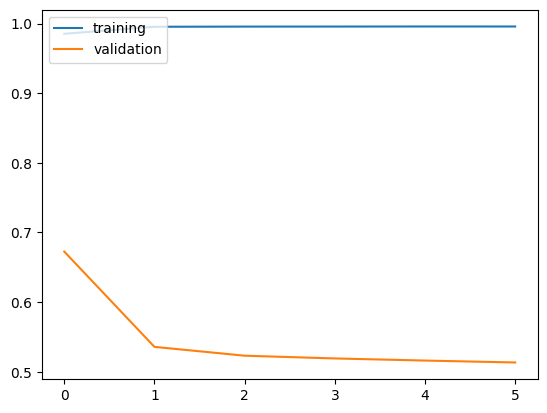

In [31]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['training', 'validation'], loc = 'upper left')
plt.show()

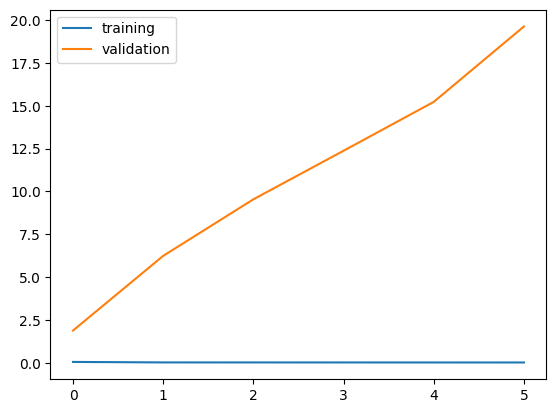

In [32]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['training', 'validation'], loc = 'upper left')
plt.show()

# Evaluating model

In [33]:
model.evaluate(x_test, y_test)

1250/1250 [==============================] - 2s 2ms/step - loss: 753.0621 - accuracy: 0.5002


[753.0620727539062, 0.5001749992370605]

In [34]:
preds = model.predict(x_test)

# One hot to the original label encodings
y_true = y_test.argmax(axis=1)

# Derive the label predictions from the probability scores
y_preds = preds.argmax(axis=1)

# Compute precision, recall, f1 scores
precision = precision_score(y_true, y_preds)
recall = recall_score(y_true, y_preds)
f1_measure = f1_score(y_true, y_preds)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Measure: {f1_measure}")

1250/1250 [==============================] - 2s 2ms/step
Precision: 0.500175
Recall: 1.0
F1-Measure: 0.6668222040761911


In [35]:
roc_auc_score(y_true, y_preds)

0.5

Text(50.722222222222214, 0.5, 'True Label')

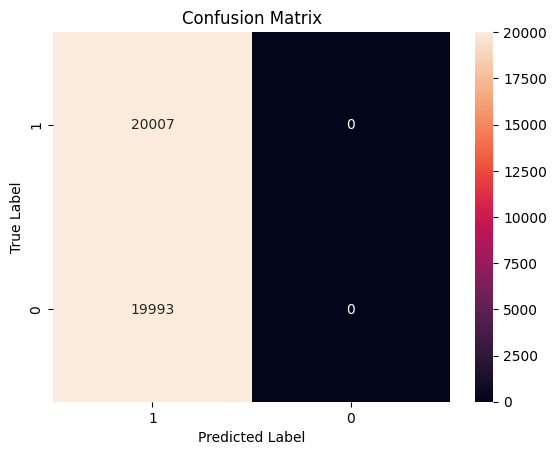

In [36]:
cm = confusion_matrix(y_true, y_preds)
plt.title("Confusion Matrix")
ax = sns.heatmap(cm, annot=True, fmt='0.0f')
ax.invert_yaxis()
ax.invert_xaxis()
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

In [37]:
tn, fp, fn, tp = cm.ravel()
print("True Negative:", tn)
print("False Negative:", fn)
print("True Positive:", tp)
print("False Positive:", fp)

True Negative: 0
False Negative: 0
True Positive: 20007
False Positive: 19993
